## Imports

In [1]:
import numpy as np
from keras.models import load_model
from sklearn.metrics import roc_auc_score, roc_curve
from methods.load_data import load_ucsf
from methods.visualisation import plot_pipeline_examples

IMAGE_SIZE = 128
CLASSIFIER_PATH = "models/best_classification_model.keras"
SEGMENTATION_PATH = "models/best_segmentation_model.keras"

c:\Users\GGPC\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Get dataset

In [2]:
_, _, x_val, y_val, x_test, y_test = load_ucsf(debug=False, classification=True, image_size=IMAGE_SIZE)
_, _, _, _, x_test_seg, y_test_seg = load_ucsf(debug=False, classification=False, basic_mask=True, image_size=IMAGE_SIZE)

y_test = np.asarray(y_test).astype(int)
y_val = np.asarray(y_val).astype(int)
positive = y_test == 1

assert positive.sum() == len(x_test_seg), (positive.sum(), len(x_test_seg)) # Check the sizes are the same
assert np.allclose(x_test[positive][:200], x_test_seg[:200])

y_test_seg = (np.asarray(y_test_seg).reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 1) > 0)
true_masks = np.zeros((len(x_test), IMAGE_SIZE, IMAGE_SIZE, 1), dtype=bool)
true_masks[positive] = y_test_seg
print(f"Test slices: {len(x_test)}, tumour-positive: {positive.sum()}")

loading dataset...
dataset loaded.
No data leakage of patient ids in train, validation and test splits
loading dataset...
dataset loaded.
No data leakage of patient ids in train, validation and test splits
Test slices: 12555, tumour-positive: 5022


## Load models

In [3]:
classifier = load_model(CLASSIFIER_PATH, compile=False)
segmenter = load_model(SEGMENTATION_PATH, compile=False)

print(classifier.input_shape, segmenter.input_shape)

(None, 128, 128, 3) (None, 128, 128, 3)


## Set Threshold for Classifier

In [4]:
val_proba = classifier.predict(x_val, batch_size=64, verbose=0).ravel()
fpr, tpr, thresholds = roc_curve(y_val, val_proba)    # False and true positive rate
CLASS_THRESHOLD = thresholds[np.argmax(tpr - fpr)]    # Youden's J
SEG_THRESHOLD = 0.5
print(f"Classifier threshold: {CLASS_THRESHOLD:.3f}")

Classifier threshold: 0.303


## Run Combined Model Pipeline

In [5]:
def run_pipeline(x, classifier, segmenter, class_threshold=CLASS_THRESHOLD, seg_threshold=SEG_THRESHOLD, batch_size=64):
    """Classify every slice, then segment only the flagged ones."""
    class_proba = classifier.predict(x, batch_size=batch_size, verbose=0).ravel()
    flagged = class_proba >= class_threshold
    masks = np.zeros((len(x), IMAGE_SIZE, IMAGE_SIZE, 1), dtype=bool)
    if flagged.any():
        seg_proba = segmenter.predict(x[flagged], batch_size=batch_size, verbose=0)
        masks[flagged] = seg_proba >= seg_threshold
    return class_proba, flagged, masks

class_proba, flagged, pred_masks = run_pipeline(x_test, classifier, segmenter)

## Evaluate Classification

In [ ]:
tp = int((flagged & positive).sum())
fn = int((~flagged & positive).sum())
fp = int((flagged & ~positive).sum())
tn = int((~flagged & ~positive).sum())

print(f"Test AUC: {roc_auc_score(y_test, class_proba):.4f}")
print(f"Flagged correctly: {tp}, missed tumour slices: {fn}, false alarms: {fp}, correct rejections: {tn}")
print(f"Sensitivity: {tp / (tp + fn):.3f}, Specificity: {tn / (tn + fp):.3f}")

Test AUC: 0.9485
Flagged correctly: 4124, missed tumour slices: 898, false alarms: 598, correct rejections: 6935
Sensitivity: 0.821, Specificity: 0.921


## Evaluate Segmentation

In [7]:
def mean_iou_nonempty(inter, union, mask=None):
    valid = union > 0
    if mask is not None:
        valid &= mask
    if not valid.any():
        return float("nan")
    return np.mean(inter[valid] / union[valid])

def iou_counts(pred, true):
    pred = pred.reshape(len(pred), -1).astype(bool)
    true = true.reshape(len(true), -1).astype(bool)
    return (pred & true).sum(axis=1), (pred | true).sum(axis=1)

segment_pred = segmenter.predict(x_test_seg, batch_size=64, verbose=0) >= SEG_THRESHOLD

inter, union = iou_counts(segment_pred, y_test_seg)
print(f"Segmenter alone | pooled IoU: {inter.sum() / union.sum():.4f} | mean non-empty-slice IoU: {mean_iou_nonempty(inter, union):.4f}")

inter, union = iou_counts(pred_masks, true_masks)
print(f"Pipeline (tumour) | mean per-slice IoU: {mean_iou_nonempty(inter, union, positive):.4f}")

print(f"Pipeline (all) | pooled IoU: {inter.sum() / union.sum():.4f}")

Segmenter alone | pooled IoU: 0.7604 | mean non-empty-slice IoU: 0.6367
Pipeline (tumour) | mean per-slice IoU: 0.5944
Pipeline (all) | pooled IoU: 0.7411


## Plot Pipeline Segmentation Results

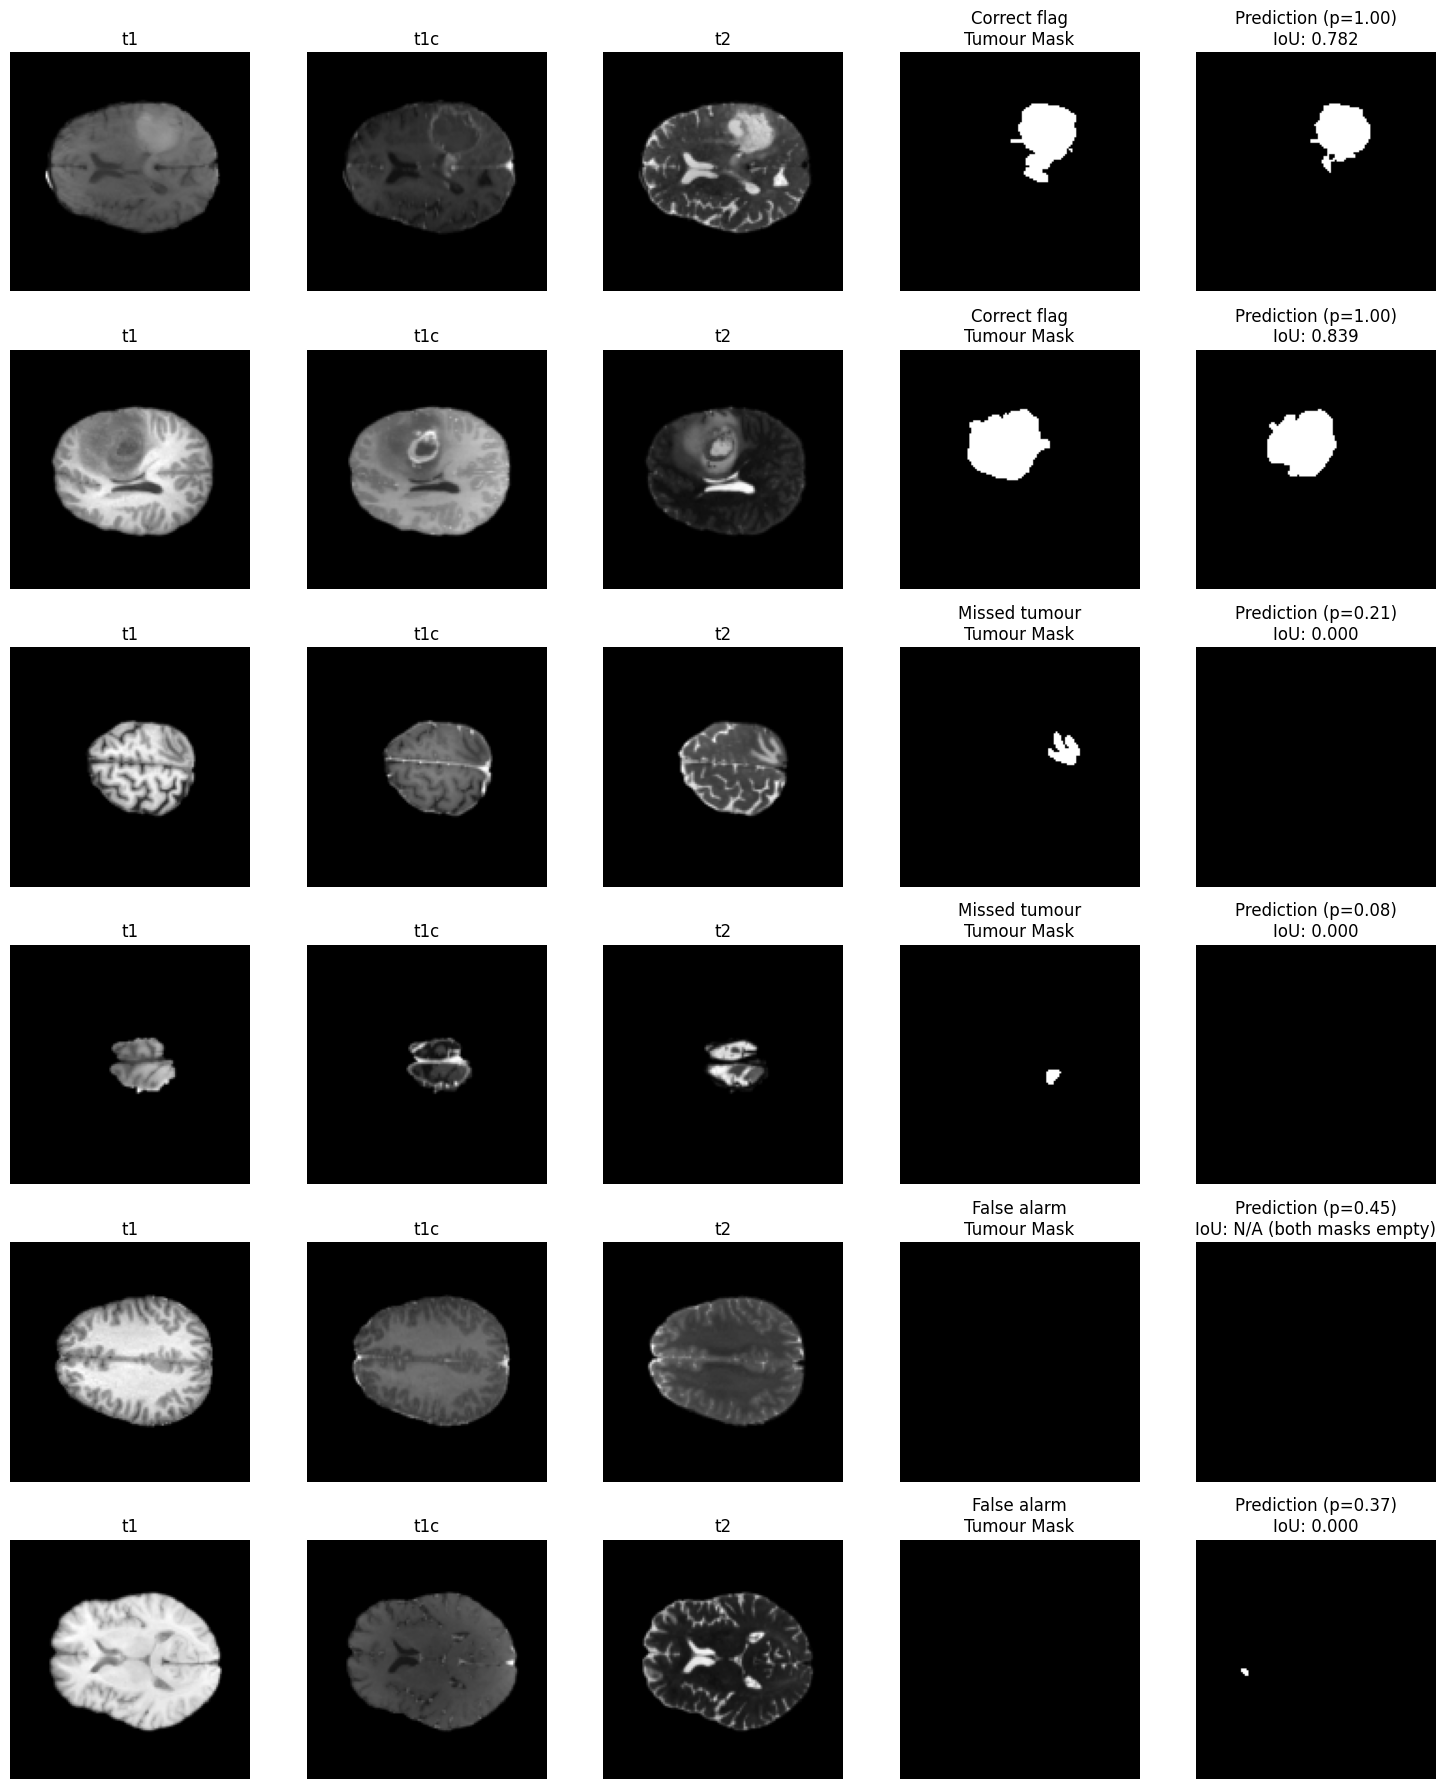

In [8]:
def picks_labels():
    rng = np.random.default_rng(1606009)
    groups = [("Correct flag", np.where(flagged & positive)[0]),
              ("Missed tumour", np.where(~flagged & positive)[0]),
              ("False alarm", np.where(flagged & ~positive)[0])]
    picks, labels = [], []
    for name, pool in groups:
        if len(pool):
            chosen = rng.choice(pool, size=min(2, len(pool)), replace=False)
            picks += list(chosen)
            labels += [name] * len(chosen)
    return picks, labels

picks, labels = picks_labels()
plot_pipeline_examples(x_test, true_masks, class_proba, pred_masks, picks, labels)